## Imports

In [19]:
from collections import Counter, defaultdict
from pathlib import Path
import sys
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import torch
from skimage.measure import regionprops
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_config, get_path
from src.utils.data import (
    get_train_images_dir,
    get_test_images_dir,
    get_annotations_path,
    load_annotations,
    remove_duplicate_annotations
)
from src.processing.masks import build_masks
from src.splitting.split import split_masks
from src.datasets.segmentation import SegmentationDataset, InferenceDataset
from src.training.dataloaders import create_dataloaders
from src.models.unet import UNet
from src.training.losses import BCEDiceLoss
from src.training.trainer import train_model
from src.processing.masks import get_connected_components, calculate_iou, filter_components_by_area
from src.utils.submission import (
    masks_to_submission,
    save_submission,
)

PROJECT_ROOT = get_project_root()
CONFIG = load_config()

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Darío\Desktop\KAGGLE\kaggle_solar_filament_segmentation


## Load data

In [3]:
RAW_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["raw_data_dir"]

TRAIN_IMAGES_DIR = get_train_images_dir(RAW_DATA_DIR)
TEST_IMAGES_DIR = get_test_images_dir(RAW_DATA_DIR)
ANNOTATIONS_PATH = get_annotations_path(RAW_DATA_DIR)

annotations = load_annotations(ANNOTATIONS_PATH)

In [4]:
annotations_clean = remove_duplicate_annotations(annotations)

print(f"Images: {len(annotations_clean['images']):,}")
print(f"Annotations: {len(annotations_clean['annotations']):,}")

Images: 707
Annotations: 5,209


## Build masks

In [5]:
final_masks = build_masks(annotations_clean)

In [6]:
file_name = next(iter(final_masks))

print(file_name)
print(len(final_masks[file_name]))
print(final_masks[file_name][0].shape)

20140609195854Bh.jpeg
12
(2048, 2048)


In [7]:
file_name = random.choice(list(final_masks.keys()))

mask = final_masks[file_name][0]

print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


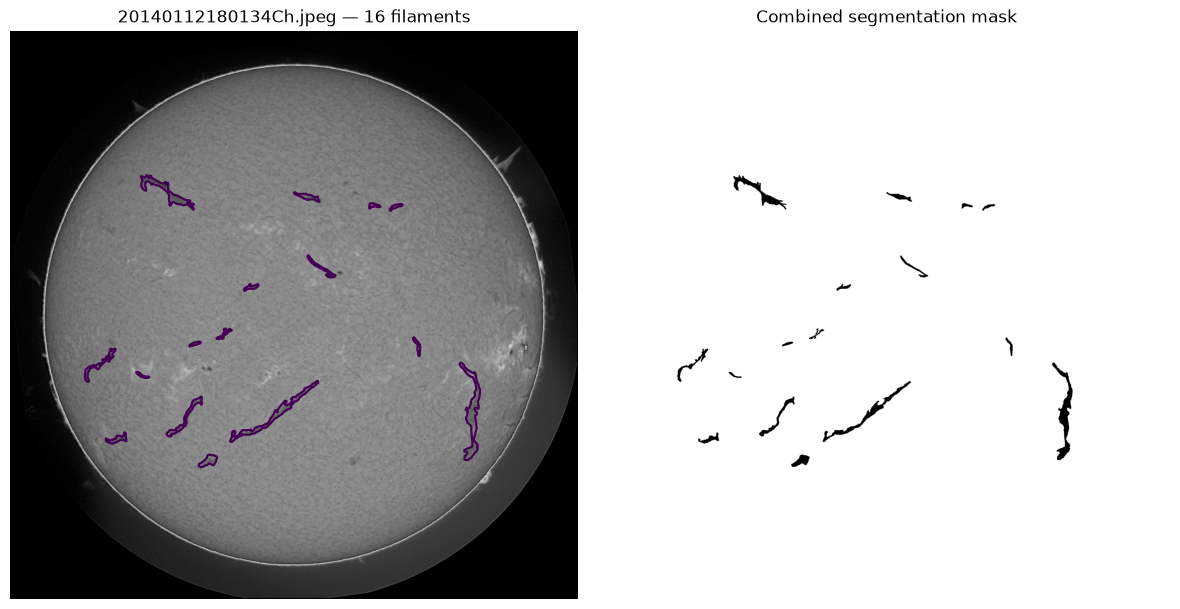

In [8]:
# Seleccionar una imagen aleatoria
file_name = random.choice(list(final_masks.keys()))

# Cargar imagen
image = np.array(
    Image.open(TRAIN_IMAGES_DIR / file_name)
)

# Obtener máscaras de la imagen
masks = final_masks[file_name]

# Combinar todas las máscaras
combined_mask = np.any(
    np.stack(masks),
    axis=0
)


# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imagen original + contornos
axes[0].imshow(image, cmap="gray")

for mask in masks:
    axes[0].contour(
        mask,
        levels=[0.5],
        linewidths=1.5,
    )

axes[0].set_title(
    f"{file_name} — {len(masks)} filaments"
)
axes[0].axis("off")


# Máscara binaria
axes[1].imshow(
    combined_mask,
    cmap="gray_r",
    vmin=0,
    vmax=1,
)

axes[1].set_title("Combined segmentation mask")
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [9]:
foreground_ratios = []

for file_name, masks in final_masks.items():

    # Combinar todos los filamentos de la imagen
    combined_mask = np.any(
        np.stack(masks),
        axis=0,
    )

    # Porcentaje de píxeles pertenecientes a filamentos
    foreground_ratio = combined_mask.mean()

    foreground_ratios.append({
        "file_name": file_name,
        "foreground_pixels": int(combined_mask.sum()),
        "foreground_ratio": foreground_ratio,
        "foreground_percentage": foreground_ratio * 100,
    })

foreground_df = pd.DataFrame(foreground_ratios)

foreground_df.head()

,file_name,foreground_pixels,foreground_ratio,foreground_percentage
0,20140609195854Bh.jpeg,18170,0.004332,0.433207
1,20111116063134Lh.jpeg,31659,0.007548,0.754809
2,20130725122934Ch.jpeg,26412,0.006297,0.629711
3,20141027025054Uh.jpeg,41715,0.009946,0.994563
4,20160714235434Lh.jpeg,20300,0.004840,0.483990


In [10]:
foreground_df["foreground_percentage"].describe()

count    707.000000
mean       0.381328
std        0.290472
min        0.010014
25%        0.143421
50%        0.333905
75%        0.550008
max        1.710892
Name: foreground_percentage, dtype: float64

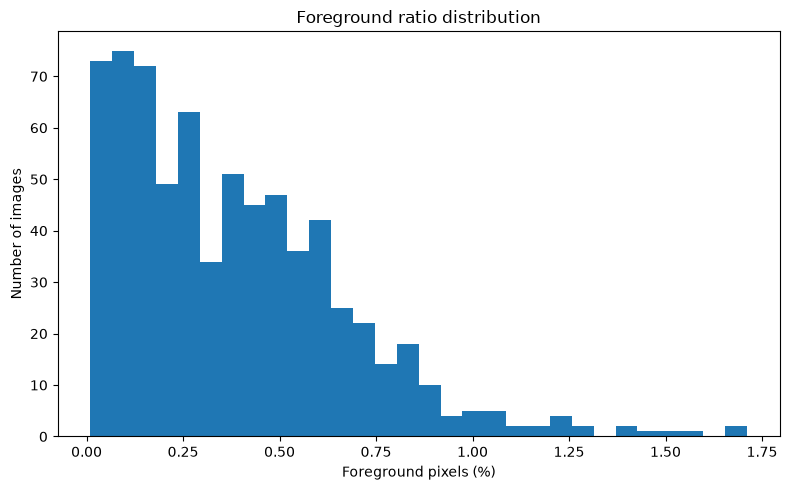

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    foreground_df["foreground_percentage"],
    bins=30,
)

ax.set_xlabel("Foreground pixels (%)")
ax.set_ylabel("Number of images")
ax.set_title("Foreground ratio distribution")

plt.tight_layout()
plt.show()

### Foreground ratio

The segmented filaments occupy a relatively small fraction of each image, with a mean foreground ratio of **0.38%** and a median of **0.33%**. However, the variability across images is considerable, ranging from **0.01% to 1.71%**.

This confirms a strong **class imbalance** between filament and background pixels. Therefore, using a standard binary cross-entropy loss alone may cause the model to favor the background class.

## Splitting

In [12]:
train_masks, val_masks, test_masks = split_masks(
    final_masks,
    train_size=0.8,
    val_size=0.1,
    test_size=0.1,
    random_state=42,
)

print(f"Train:      {len(train_masks):,} images")
print(f"Validation: {len(val_masks):,} images")
print(f"Test:       {len(test_masks):,} images")
print(f"Total:      {len(final_masks):,} images")

Train:      565 images
Validation: 71 images
Test:       71 images
Total:      707 images


## Pytorch datasets & dataloaders

In [13]:
train_dataset = SegmentationDataset(
    masks=train_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

val_dataset = SegmentationDataset(
    masks=val_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

test_dataset = SegmentationDataset(
    masks=test_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=1,
    num_workers=0,
    pin_memory=True,
)

images, masks_batch = next(iter(train_loader))

print(f"Train batches: {len(train_loader)}")
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape:  {masks_batch.shape}")

Train batches: 565
Image batch shape: torch.Size([1, 1, 2048, 2048])
Mask batch shape:  torch.Size([1, 1, 2048, 2048])


## Building the U-Net

In [14]:
model = UNet(
    in_channels=1,
    out_channels=1,
    base_channels=16,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070


## Loading our loss function

In [15]:
loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5,
)

## Training

In [ ]:
models_dir = get_path(CONFIG["paths"]["models_dir"])

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=7,
    scheduler_patience=3,
    scheduler_factor=0.5,
    threshold=0.5,
    device=device,
    use_amp=True,
    checkpoint_path=models_dir / "unet_checkpoint.pth",
)

Epoch 01/50 | Train Loss: 0.5170 | Train Dice: 0.2430 | Train IoU: 0.1618 | Val Loss: 0.5106 | Val Dice: 0.0034 | Val IoU: 0.0019 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.0034)
Epoch 02/50 | Train Loss: 0.2652 | Train Dice: 0.5219 | Train IoU: 0.3658 | Val Loss: 0.2756 | Val Dice: 0.4797 | Val IoU: 0.3310 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.4797)
Epoch 03/50 | Train Loss: 0.2408 | Train Dice: 0.5468 | Train IoU: 0.3895 | Val Loss: 0.2455 | Val Dice: 0.5349 | Val IoU: 0.3823 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5349)
Epoch 04/50 | Train Loss: 0.2250 | Train Dice: 0.5751 | Train IoU: 0.4151 | Val Loss: 0.3100 | Val Dice: 0.4067 | Val IoU: 0.2735 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 0.2173 | Train Dice: 0.5889 | Train IoU: 0.4286 | Val Loss: 0.2789 | Val Dice: 0.4704 | Val IoU: 0.3286 | LR: 1.00e-03
Epoch 06/50 | Train Loss: 0.2122 | Train Dice: 0.5988 | Train IoU: 0.4380 | Val Loss: 0.2389 | Val Dice: 0.5452 | Val IoU: 0.3953 | LR: 1.00e-03
  -> Be

## Inference

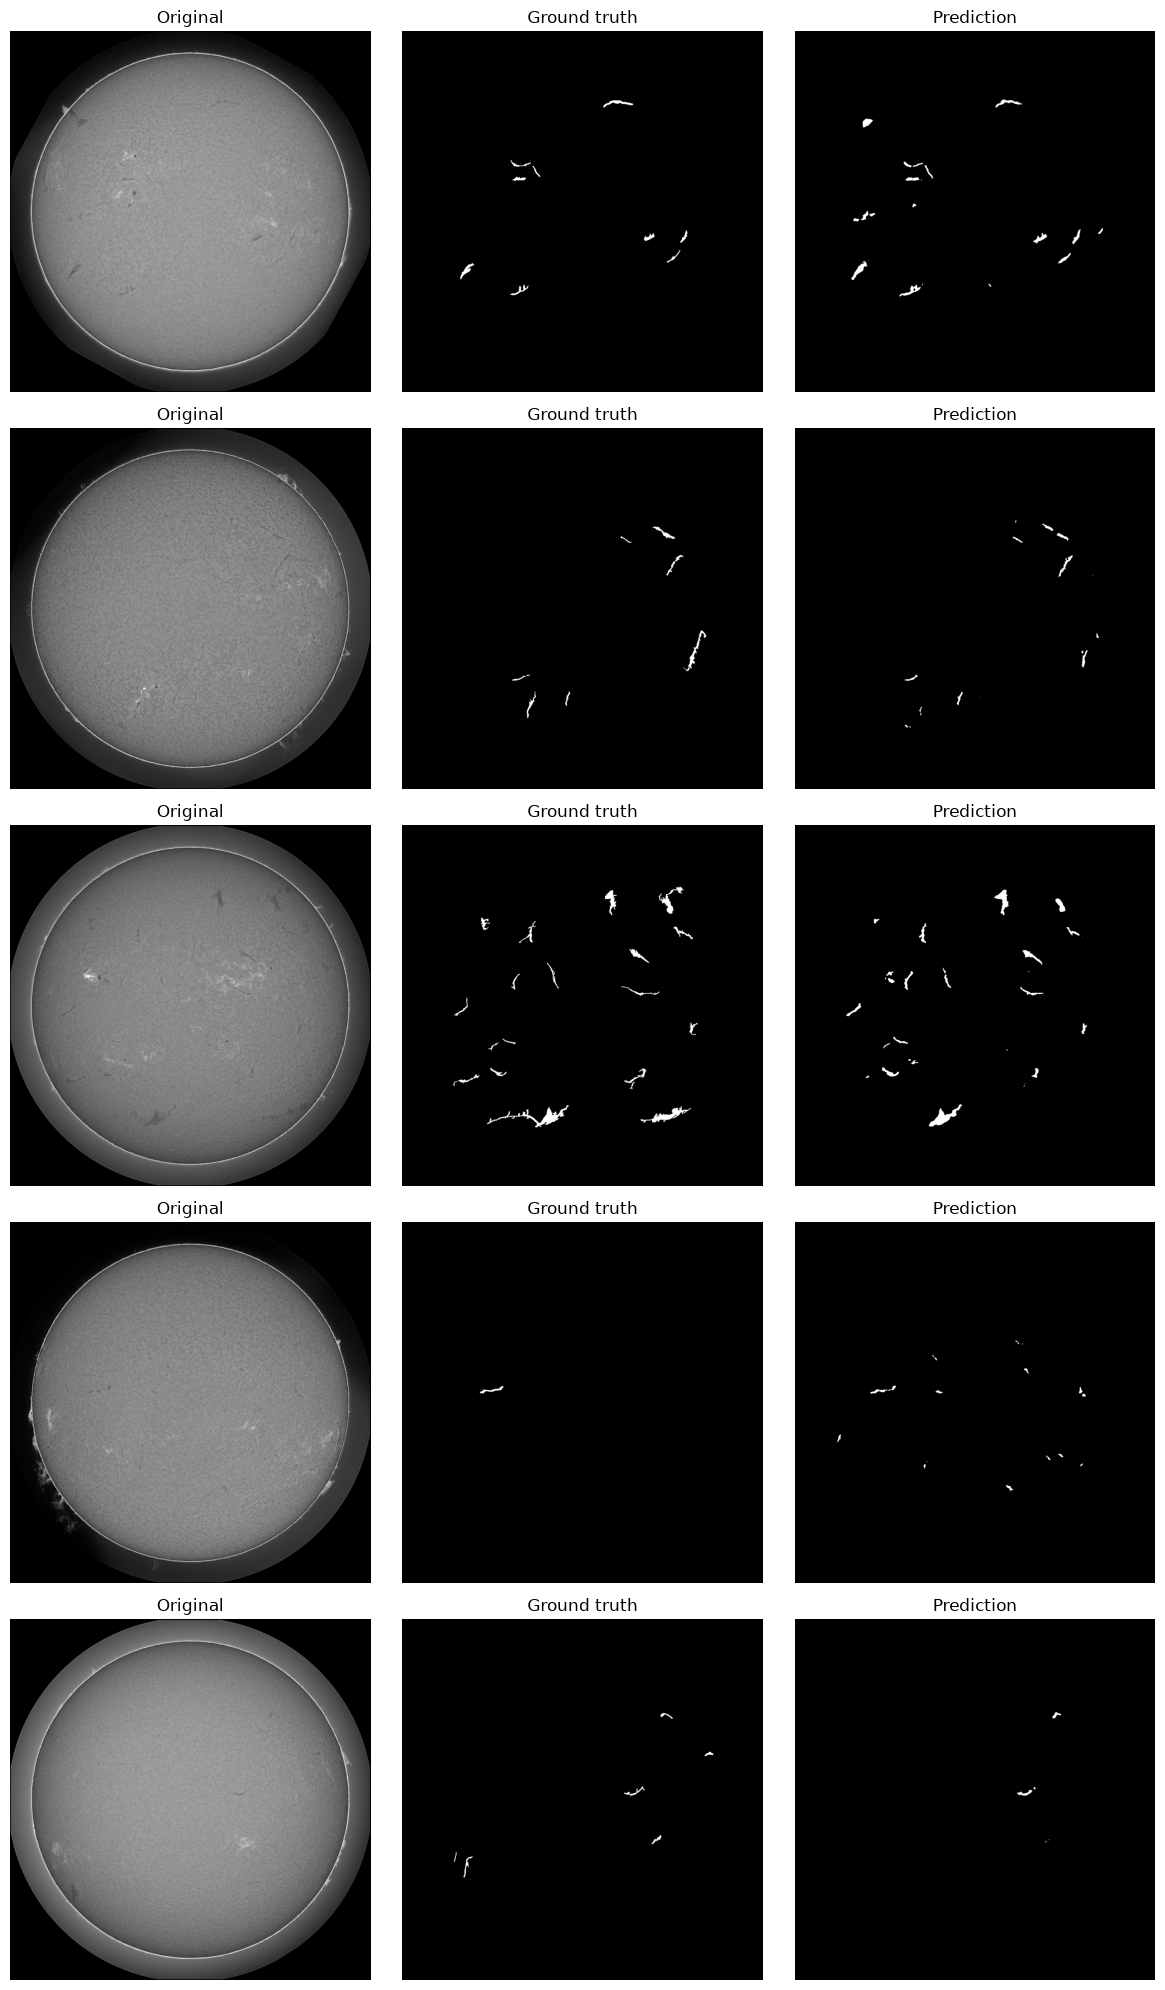

In [ ]:
models_dir = get_path(CONFIG["paths"]["models_dir"])

checkpoint_path = models_dir / "unet_checkpoint.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

num_samples = 5

indices = random.sample(
    range(len(val_dataset)),
    num_samples,
)

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples),
)

model.eval()

with torch.no_grad():
    for row, index in enumerate(indices):
        image, mask = val_dataset[index]

        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probabilities = torch.sigmoid(logits)

        predicted_mask = (
            probabilities >= 0.5
        ).float()

        image = image.squeeze(0).numpy()
        mask = mask.squeeze(0).numpy()
        predicted_mask = predicted_mask.squeeze().cpu().numpy()

        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title("Original")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("Ground truth")

        axes[row, 2].imshow(predicted_mask, cmap="gray")
        axes[row, 2].set_title("Prediction")

        for ax in axes[row]:
            ax.axis("off")

plt.tight_layout()
plt.show()

### Get connected components

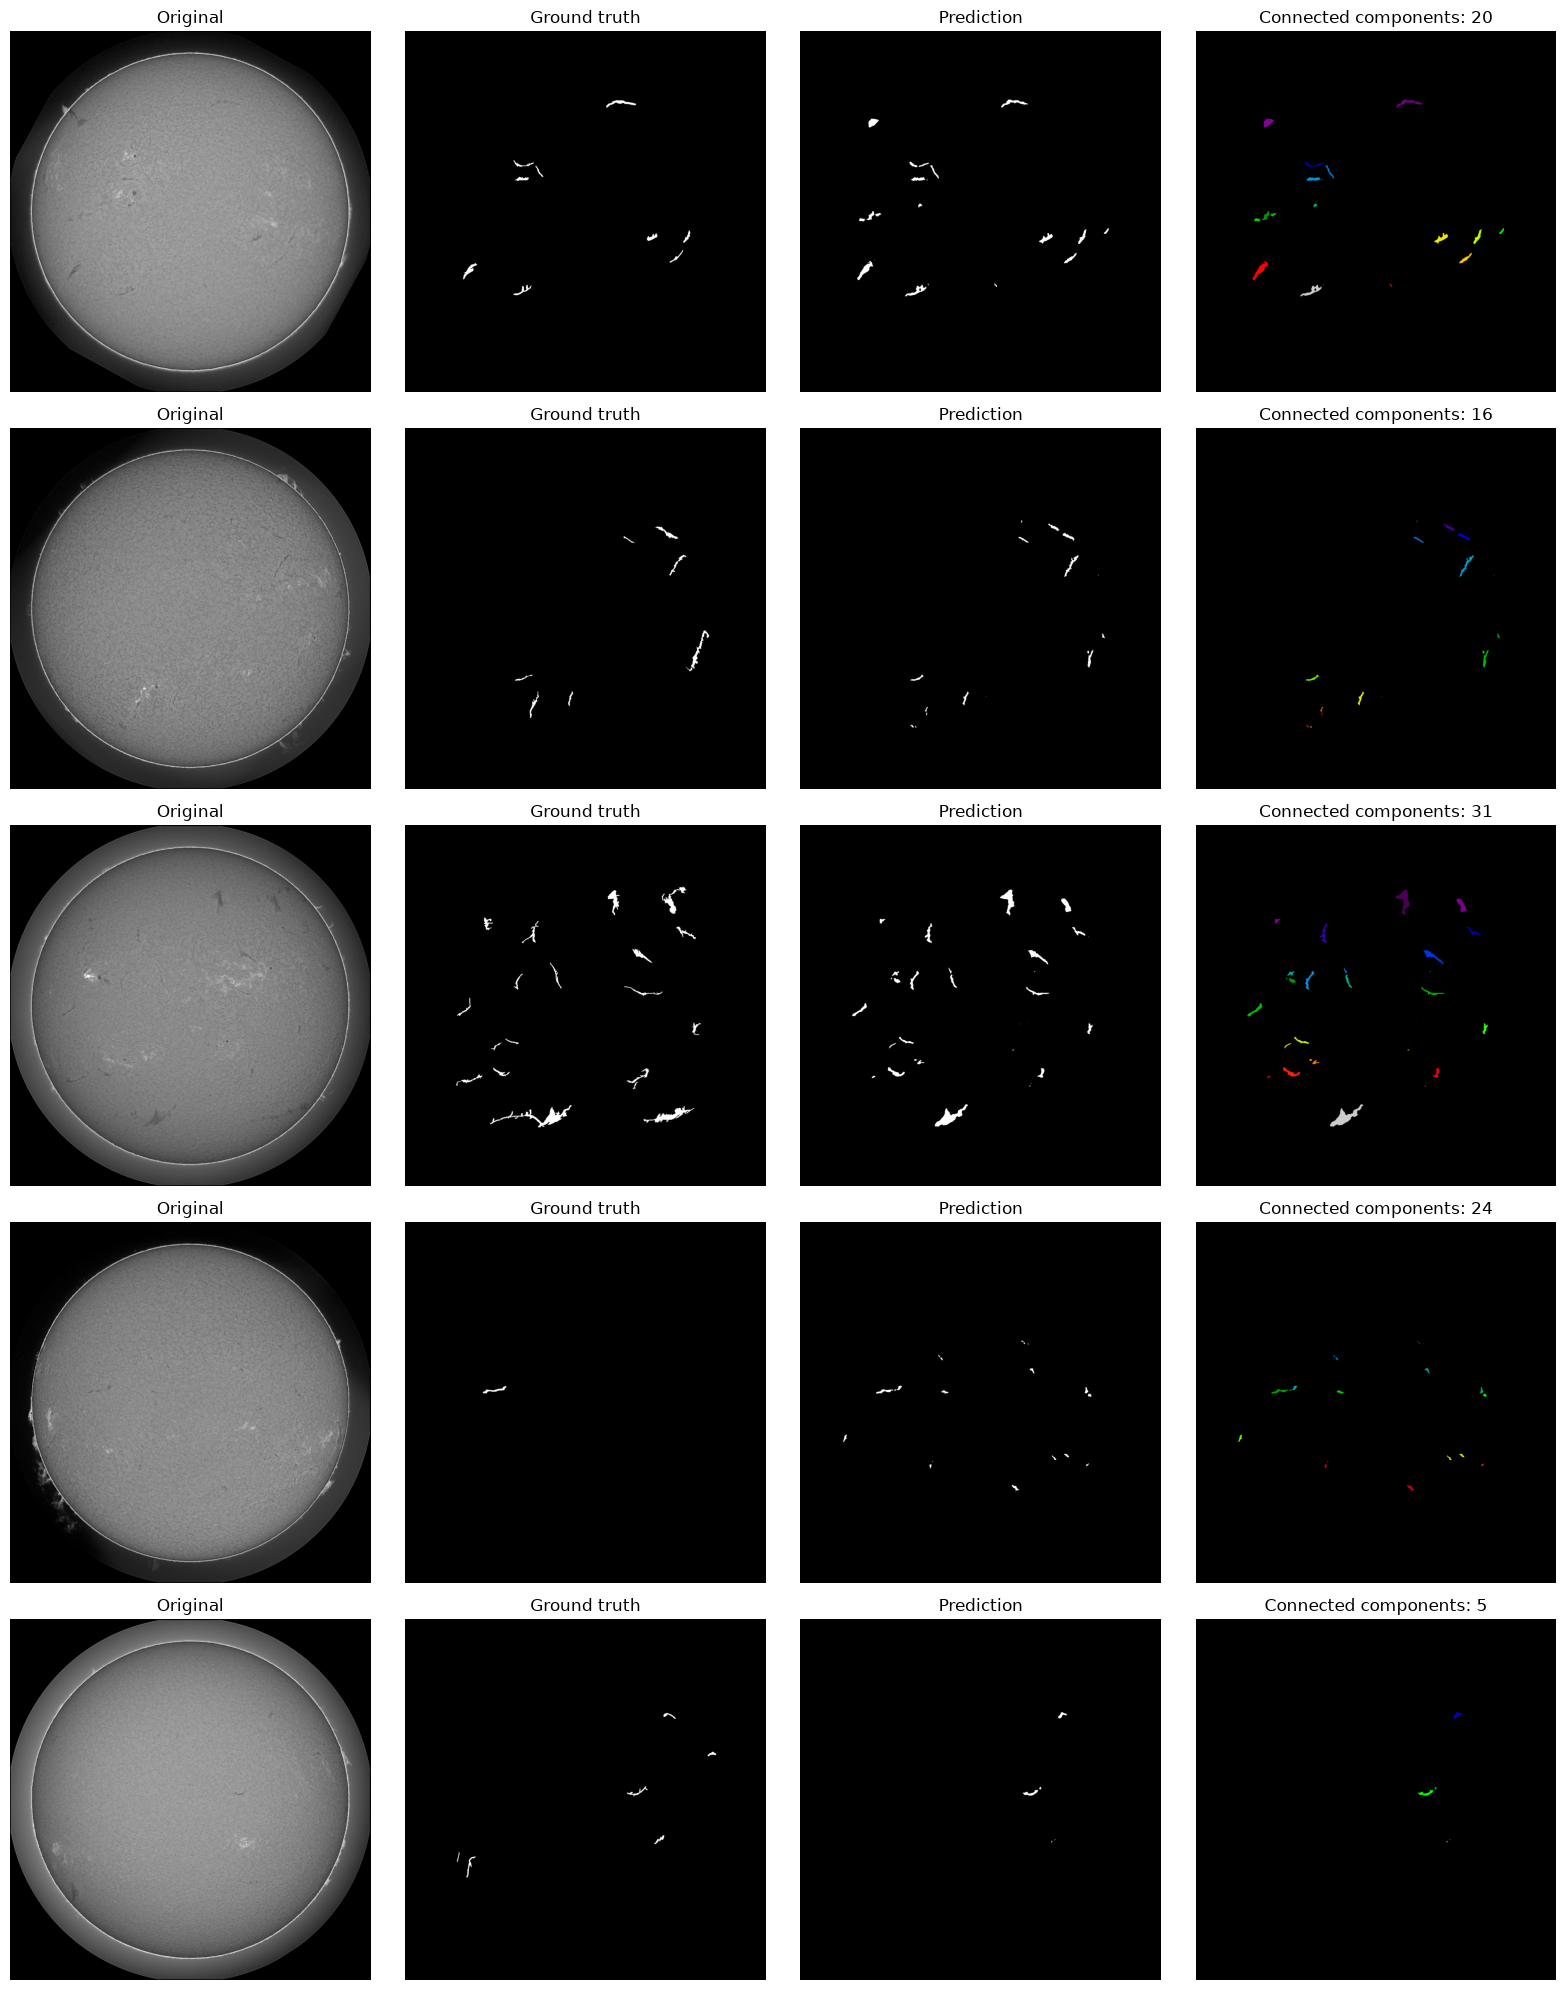

In [ ]:
fig, axes = plt.subplots(
    num_samples,
    4,
    figsize=(16, 4 * num_samples),
)

model.eval()

with torch.no_grad():
    for row, index in enumerate(indices):
        image, mask = val_dataset[index]

        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probabilities = torch.sigmoid(logits)

        predicted_mask = (
            probabilities >= 0.5
        ).float()

        predicted_mask = predicted_mask.squeeze().cpu().numpy()

        image = image.squeeze(0).numpy()
        mask = mask.squeeze(0).numpy()

        components, num_components = get_connected_components(
            predicted_mask
        )

        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title("Original")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("Ground truth")

        axes[row, 2].imshow(predicted_mask, cmap="gray")
        axes[row, 2].set_title("Prediction")

        axes[row, 3].imshow(components, cmap="nipy_spectral")
        axes[row, 3].set_title(
            f"Connected components: {num_components}"
        )

        for ax in axes[row]:
            ax.axis("off")

plt.tight_layout()
plt.show()

### Predicted vs. ground-truth filament size

To better understand the segmentation errors produced by the U-Net, we compare the geometric properties of the predicted filament regions with those of the ground-truth annotations.

We analyse not only the **area**, but also the **length**, **width**, and **aspect ratio** of each region. This allows us to determine whether the model tends to produce filaments that are systematically too small, too short, too wide, or differently shaped than the ground-truth filaments.

The analysis is performed on the validation set, treating each connected predicted component as an individual region. This provides a first characterization of the model's instance-level predictions and can help identify patterns such as **fragmentation, excessively small predictions, or incorrect filament shapes**.

These geometric properties are computed from labelled regions using `skimage.measure.regionprops`.

In [ ]:
gt_records = []

for filename, masks in val_masks.items():
    for filament_id, mask in enumerate(masks, start=1):
        properties = regionprops(mask.astype(np.uint8))

        if not properties:
            continue

        region = properties[0]

        min_row, min_col, max_row, max_col = region.bbox

        height = max_row - min_row
        width = max_col - min_col

        length = max(height, width)
        width = min(height, width)

        gt_records.append(
            {
                "filename": filename,
                "filament_id": filament_id,
                "area": region.area,
                "length": length,
                "width": width,
                "aspect_ratio": length / width if width > 0 else np.nan,
            }
        )

gt_df = pd.DataFrame(gt_records)

gt_df.head()

,filename,filament_id,area,length,width,aspect_ratio
0,20210626133950Bh.jpeg,1,1736.0,136,25,5.440000
1,20210626133950Bh.jpeg,2,776.0,63,60,1.050000
2,20210626133950Bh.jpeg,3,570.0,48,36,1.333333
3,20140816072814Th.jpeg,1,4758.0,226,46,4.913043
4,20140816072814Th.jpeg,2,1321.0,60,51,1.176471


In [ ]:
pred_records = []

model.eval()

with torch.no_grad():
    for index in range(len(val_dataset)):
        image, _ = val_dataset[index]
        filename = val_dataset.filenames[index]

        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probabilities = torch.sigmoid(logits)

        predicted_mask = (
            probabilities >= 0.5
        ).squeeze().cpu().numpy()

        components, num_components = get_connected_components(
            predicted_mask
        )

        for component_id in range(1, num_components + 1):
            component_mask = components == component_id

            region = regionprops(
                component_mask.astype(np.uint8)
            )[0]

            min_row, min_col, max_row, max_col = region.bbox

            height = max_row - min_row
            width = max_col - min_col

            length = max(height, width)
            width = min(height, width)

            pred_records.append(
                {
                    "filename": filename,
                    "component_id": component_id,
                    "area": region.area,
                    "length": length,
                    "width": width,
                    "aspect_ratio": length / width if width > 0 else np.nan,
                }
            )

pred_df = pd.DataFrame(pred_records)

pred_df.head()

,filename,component_id,area,length,width,aspect_ratio
0,20210626133950Bh.jpeg,1,28.0,8,7,1.142857
1,20210626133950Bh.jpeg,2,5.0,3,2,1.500000
2,20210626133950Bh.jpeg,3,6.0,3,3,1.000000
3,20210626133950Bh.jpeg,4,400.0,46,16,2.875000
4,20140816072814Th.jpeg,1,660.0,45,40,1.125000


In [ ]:
gt_df[["area", "length", "width", "aspect_ratio"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,area,length,width,aspect_ratio
count,546.000000,546.000000,546.000000,546.000000
mean,1994.877289,119.580586,66.686813,2.020652
std,2177.295172,86.214826,50.102564,1.044755
min,169.000000,20.000000,8.000000,1.000000
1%,225.450000,30.450000,12.450000,1.012317
5%,335.250000,40.250000,20.000000,1.054067
10%,467.500000,46.000000,24.000000,1.111096
25%,721.750000,61.250000,34.000000,1.312842
50%,1274.500000,94.500000,52.000000,1.691154
75%,2335.500000,147.750000,81.000000,2.338652


In [ ]:
pred_df[["area", "length", "width", "aspect_ratio"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,area,length,width,aspect_ratio
count,1197.000000,1197.000000,1197.000000,1197.000000
mean,850.973266,53.378446,31.472849,1.723338
std,1243.895179,54.859852,32.020457,0.707848
min,1.000000,1.000000,1.000000,1.000000
1%,1.000000,1.000000,1.000000,1.000000
5%,5.000000,3.000000,2.000000,1.000000
10%,13.000000,5.000000,4.000000,1.050000
25%,82.000000,14.000000,10.000000,1.212121
50%,412.000000,39.000000,23.000000,1.500000
75%,1054.000000,73.000000,43.000000,2.000000


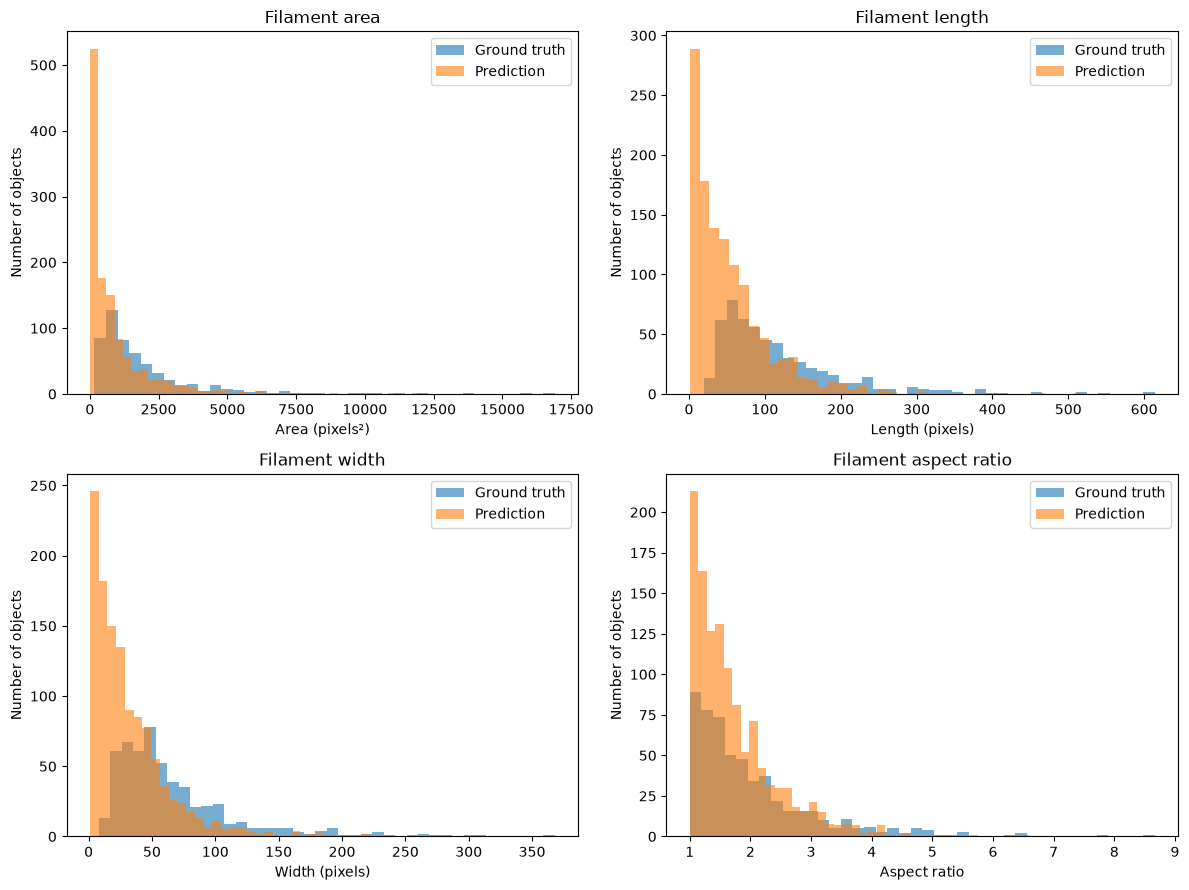

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(
    gt_df["area"],
    bins=40,
    alpha=0.6,
    label="Ground truth",
)

axes[0, 0].hist(
    pred_df["area"],
    bins=40,
    alpha=0.6,
    label="Prediction",
)

axes[0, 0].set_xlabel("Area (pixels²)")
axes[0, 0].set_ylabel("Number of objects")
axes[0, 0].set_title("Filament area")
axes[0, 0].legend()


axes[0, 1].hist(
    gt_df["length"],
    bins=40,
    alpha=0.6,
    label="Ground truth",
)

axes[0, 1].hist(
    pred_df["length"],
    bins=40,
    alpha=0.6,
    label="Prediction",
)

axes[0, 1].set_xlabel("Length (pixels)")
axes[0, 1].set_ylabel("Number of objects")
axes[0, 1].set_title("Filament length")
axes[0, 1].legend()


axes[1, 0].hist(
    gt_df["width"],
    bins=40,
    alpha=0.6,
    label="Ground truth",
)

axes[1, 0].hist(
    pred_df["width"],
    bins=40,
    alpha=0.6,
    label="Prediction",
)

axes[1, 0].set_xlabel("Width (pixels)")
axes[1, 0].set_ylabel("Number of objects")
axes[1, 0].set_title("Filament width")
axes[1, 0].legend()


axes[1, 1].hist(
    gt_df["aspect_ratio"],
    bins=40,
    alpha=0.6,
    label="Ground truth",
)

axes[1, 1].hist(
    pred_df["aspect_ratio"],
    bins=40,
    alpha=0.6,
    label="Prediction",
)

axes[1, 1].set_xlabel("Aspect ratio")
axes[1, 1].set_ylabel("Number of objects")
axes[1, 1].set_title("Filament aspect ratio")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

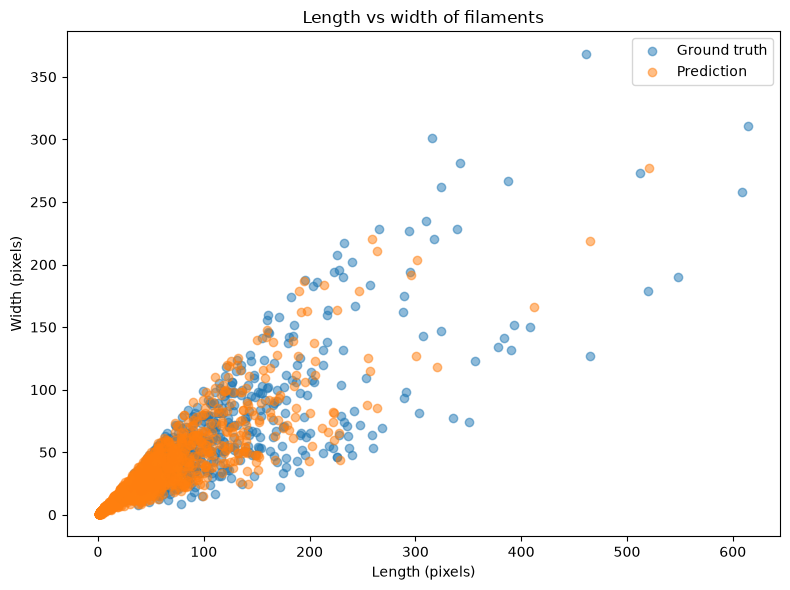

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    gt_df["length"],
    gt_df["width"],
    alpha=0.5,
    label="Ground truth",
)

plt.scatter(
    pred_df["length"],
    pred_df["width"],
    alpha=0.5,
    label="Prediction",
)

plt.xlabel("Length (pixels)")
plt.ylabel("Width (pixels)")
plt.title("Length vs width of filaments")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Ground truth": gt_df[
        ["area", "length", "width", "aspect_ratio"]
    ].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    ).T["mean"],

    "Prediction": pred_df[
        ["area", "length", "width", "aspect_ratio"]
    ].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    ).T["mean"],
})

statistics = ["mean", "10%", "25%", "50%", "75%", "90%", "95%"]

gt_stats = (
    gt_df[["area", "length", "width", "aspect_ratio"]]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    .loc[statistics]
    .T
)

pred_stats = (
    pred_df[["area", "length", "width", "aspect_ratio"]]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
    .loc[statistics]
    .T
)

comparison = pd.concat(
    {
        "Ground truth": gt_stats,
        "Prediction": pred_stats,
    },
    axis=1,
)

comparison

Ground truth                                                    \
                     mean         10%         25%          50%          75%   
area          1994.877289  467.500000  721.750000  1274.500000  2335.500000   
length         119.580586   46.000000   61.250000    94.500000   147.750000   
width           66.686813   24.000000   34.000000    52.000000    81.000000   
aspect_ratio     2.020652    1.111096    1.312842     1.691154     2.338652   

                                        Prediction                           \
                      90%          95%        mean    10%        25%    50%   
area          4455.500000  6038.000000  850.973266  13.00  82.000000  412.0   
length         226.000000   290.500000   53.378446   5.00  14.000000   39.0   
width          124.500000   172.250000   31.472849   4.00  10.000000   23.0   
aspect_ratio     3.349374     4.157197    1.723338   1.05   1.212121    1.5   

                                                
                 75%          90%          95%  
area          1054.0  2289.200000  3274.800000  
length          73.0   122.000000   156.400000  
width           43.0    67.000000    90.200000  
aspect_ratio     2.0     2.673684     3.135238

In [ ]:
ratio = pred_stats / gt_stats

ratio

,mean,10%,25%,50%,75%,90%,95%
area,0.426579,0.027807,0.113613,0.323264,0.451295,0.513792,0.542365
length,0.446381,0.108696,0.228571,0.412698,0.494078,0.539823,0.538382
width,0.471950,0.166667,0.294118,0.442308,0.530864,0.538153,0.523657
aspect_ratio,0.852863,0.945012,0.923280,0.886968,0.855193,0.798264,0.754171


In [ ]:
relative_difference = (pred_stats / gt_stats - 1) * 100

relative_difference

,mean,10%,25%,50%,75%,90%,95%
area,-57.342075,-97.219251,-88.638725,-67.673597,-54.870477,-48.620806,-45.763498
length,-55.361946,-89.130435,-77.142857,-58.730159,-50.592217,-46.017699,-46.161790
width,-52.804989,-83.333333,-70.588235,-55.769231,-46.913580,-46.184739,-47.634253
aspect_ratio,-14.713741,-5.498751,-7.671976,-11.303161,-14.480667,-20.173615,-24.582883



The predicted regions are substantially smaller than the ground-truth filaments across all size-related measurements.

At the median, predicted regions have approximately **32% of the ground-truth area**, **41% of the length**, and **44% of the width**. The mean ratios show a similar pattern, with predictions reaching approximately **43% of the ground-truth area**, **45% of the length**, and **47% of the width**.

In contrast, the **aspect ratio** is considerably closer to the ground truth, with a median ratio of approximately **0.89**. This suggests that the predicted regions generally preserve the elongated shape of the filaments, while being substantially smaller.

Overall, this analysis suggests that the main issue is not a completely incorrect filament geometry, but rather **under-segmentation of the filament regions**. However, since these statistics compare the overall distributions of predicted components and ground-truth filaments rather than matched instances, this hypothesis should be verified through an instance-level comparison based on IoU.

In [ ]:
matches = []

model.eval()

with torch.no_grad():
    for index in range(len(val_dataset)):

        image, _ = val_dataset[index]
        filename = val_dataset.filenames[index]

        # Ground-truth masks
        gt_masks = val_masks[filename]

        # Model prediction
        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probabilities = torch.sigmoid(logits)

        predicted_mask = (
            probabilities >= 0.5
        ).squeeze().cpu().numpy()

        # Connected components
        components, num_components = get_connected_components(
            predicted_mask
        )

        predicted_components = [
            components == component_id
            for component_id in range(1, num_components + 1)
        ]

        # ---------------------------------------------------------
        # 1. Compute IoU for every GT-prediction pair
        # ---------------------------------------------------------
        iou_matrix = np.zeros(
            (len(gt_masks), len(predicted_components)),
            dtype=np.float32,
        )

        for gt_index, gt_mask in enumerate(gt_masks):
            for pred_index, pred_mask in enumerate(predicted_components):
                iou_matrix[gt_index, pred_index] = calculate_iou(
                    gt_mask,
                    pred_mask,
                )

        # ---------------------------------------------------------
        # 2. Find all valid matches (IoU > 0.5)
        # ---------------------------------------------------------
        matched_gt_ids = set()
        matched_pred_ids = set()

        for gt_index in range(len(gt_masks)):
            for pred_index in range(len(predicted_components)):

                iou = iou_matrix[gt_index, pred_index]

                if iou > 0.5:
                    gt_id = gt_index + 1
                    pred_id = pred_index + 1

                    matches.append(
                        {
                            "filename": filename,
                            "gt_id": gt_id,
                            "pred_id": pred_id,
                            "iou": iou,
                            "match_type": "TP",
                        }
                    )

                    matched_gt_ids.add(gt_id)
                    matched_pred_ids.add(pred_id)

        # ---------------------------------------------------------
        # 3. Ground-truth filaments without a valid match -> FN
        # ---------------------------------------------------------
        for gt_index in range(len(gt_masks)):

            gt_id = gt_index + 1

            if gt_id not in matched_gt_ids:
                matches.append(
                    {
                        "filename": filename,
                        "gt_id": gt_id,
                        "pred_id": None,
                        "iou": 0.0,
                        "match_type": "FN",
                    }
                )

        # ---------------------------------------------------------
        # 4. Predicted components without a valid match -> FP
        # ---------------------------------------------------------
        for pred_index in range(len(predicted_components)):

            pred_id = pred_index + 1

            if pred_id not in matched_pred_ids:
                matches.append(
                    {
                        "filename": filename,
                        "gt_id": None,
                        "pred_id": pred_id,
                        "iou": 0.0,
                        "match_type": "FP",
                    }
                )

matches_df = pd.DataFrame(matches)

In [ ]:
matches_df = pd.DataFrame(matches)

matches_df.head()

,filename,gt_id,pred_id,iou,match_type
0,20210626133950Bh.jpeg,3.0,4.0,0.65529,TP
1,20210626133950Bh.jpeg,1.0,NaN,0.00000,FN
2,20210626133950Bh.jpeg,2.0,NaN,0.00000,FN
3,20210626133950Bh.jpeg,NaN,1.0,0.00000,FP
4,20210626133950Bh.jpeg,NaN,2.0,0.00000,FP


In [ ]:
match_counts = (
    matches_df["match_type"]
    .value_counts()
    .reindex(["TP", "FP", "FN"], fill_value=0)
)

match_summary = pd.DataFrame(
    {
        "Count": match_counts,
        "Frequency": match_counts / match_counts.sum(),
    }
)

match_summary["Frequency"] = (
    match_summary["Frequency"] * 100
).round(2)

match_summary

,Count,Frequency
match_type,,
TP,296,20.46
FP,901,62.27
FN,250,17.28


In [ ]:
confusion_matrix = pd.DataFrame(
    [
        [match_counts["TP"], match_counts["FN"]],
        [match_counts["FP"], np.nan],
    ],
    index=["Actual: Filament", "Actual: No filament"],
    columns=["Predicted: Filament", "Predicted: No filament"],
)

confusion_matrix

,Predicted: Filament,Predicted: No filament
Actual: Filament,296,250.0
Actual: No filament,901,NaN


In [ ]:
tp = match_counts["TP"]
fp = match_counts["FP"]
fn = match_counts["FN"]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0.0
)

metrics_summary = pd.DataFrame(
    {
        "Metric": ["Precision", "Recall", "F1"],
        "Value": [precision, recall, f1],
    }
)

metrics_summary

,Metric,Value
0,Precision,0.247285
1,Recall,0.542125
2,F1,0.339644


In [ ]:
match_counts = matches_df["match_type"].value_counts()

tp = match_counts.get("TP", 0)
fp = match_counts.get("FP", 0)
fn = match_counts.get("FN", 0)

print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")

sq = matches_df.loc[
    matches_df["match_type"] == "TP",
    "iou",
].mean()

rq = tp / (tp + 0.5 * fp + 0.5 * fn)

pq = sq * rq

print(f"SQ: {sq:.4f}")
print(f"RQ: {rq:.4f}")
print(f"PQ: {pq:.4f}")

TP: 296
FP: 901
FN: 250
SQ: 0.6482
RQ: 0.3396
PQ: 0.2202


### Instance-level evaluation

The model achieves **296 true positives**, but also produces **901 false positives** and **250 false negatives**. This indicates that the main weakness is **instance recognition**, with a large number of predicted components that cannot be matched to a ground-truth filament.

The **Segmentation Quality (SQ)** is considerably higher at **0.6482**, indicating that correctly matched filaments generally have a reasonable overlap with the ground truth. However, the **Recognition Quality (RQ)** is only **0.3396**, which substantially limits the overall **Panoptic Quality (PQ) of 0.2202**.

Overall, the baseline appears to be limited mainly by the **large number of false-positive components**, rather than by the quality of the segmentations that are successfully matched.

In [ ]:
prediction_records = []

model.eval()

with torch.no_grad():
    for index in range(len(val_dataset)):

        image, _ = val_dataset[index]
        filename = val_dataset.filenames[index]
        gt_masks = val_masks[filename]

        # Model prediction
        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probabilities = torch.sigmoid(logits)

        predicted_mask = (
            probabilities >= 0.5
        ).squeeze().cpu().numpy()

        # Connected components
        components, num_components = get_connected_components(
            predicted_mask
        )

        predicted_components = [
            components == component_id
            for component_id in range(1, num_components + 1)
        ]

        # ---------------------------------------------------------
        # Analyze every predicted component
        # ---------------------------------------------------------
        for pred_id, pred_mask in enumerate(
            predicted_components,
            start=1,
        ):

            # -----------------------------------------------------
            # Find the best IoU with any GT filament
            # -----------------------------------------------------
            best_iou = 0.0
            best_gt_id = None

            for gt_id, gt_mask in enumerate(
                gt_masks,
                start=1,
            ):
                iou = calculate_iou(
                    gt_mask,
                    pred_mask,
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt_id = gt_id

            # -----------------------------------------------------
            # Region properties
            # -----------------------------------------------------
            region = regionprops(
                pred_mask.astype(np.uint8)
            )[0]

            min_row, min_col, max_row, max_col = region.bbox

            height = max_row - min_row
            width = max_col - min_col

            length = max(height, width)
            width = min(height, width)

            aspect_ratio = (
                length / width
                if width > 0
                else np.nan
            )

            # -----------------------------------------------------
            # Retrieve the SAME classification from matches_df
            # -----------------------------------------------------
            current_match = matches_df[
                (matches_df["filename"] == filename)
                & (matches_df["pred_id"] == pred_id)
            ]

            if current_match.empty:
                raise ValueError(
                    f"Prediction {pred_id} in {filename} "
                    "was not found in matches_df."
                )

            current_match = current_match.iloc[0]

            original_match_type = current_match["match_type"]
            matched_gt_id = current_match["gt_id"]
            matched_iou = current_match["iou"]

            # -----------------------------------------------------
            # Refine FP classification
            # -----------------------------------------------------
            if original_match_type == "TP":
                match_type = "TP"

            else:
                match_type = (
                    "FP_overlap"
                    if best_iou > 0
                    else "FP_no_overlap"
                )

                # FP predictions have no matched GT
                matched_gt_id = None
                matched_iou = best_iou

            prediction_records.append(
                {
                    "filename": filename,
                    "pred_id": pred_id,
                    "gt_id": matched_gt_id,
                    "iou": matched_iou,
                    "best_gt_id": best_gt_id,
                    "best_iou": best_iou,
                    "match_type": match_type,
                    "area": region.area,
                    "length": length,
                    "width": width,
                    "aspect_ratio": aspect_ratio,
                }
            )

predictions_df = pd.DataFrame(prediction_records)

In [ ]:
prediction_summary = (
    predictions_df
    .groupby("match_type")[
        ["area", "length", "width", "aspect_ratio", "best_iou"]
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

prediction_summary

area                                  length                 \
              count     mean  median    min      max  count    mean median   
match_type                                                                   
FP_no_overlap   494   279.65   116.5    1.0   5828.0    494   24.26   18.0   
FP_overlap      407   738.97   465.0    1.0   5523.0    407   49.70   40.0   
TP              296  1958.48  1380.5  179.0  12025.0    296  107.04   90.0   

                        ... aspect_ratio                         best_iou  \
              min  max  ...        count  mean median  min   max    count   
match_type              ...                                                 
FP_no_overlap   1  171  ...          494  1.62   1.44  1.0  4.22      494   
FP_overlap      1  320  ...          407  1.69   1.50  1.0  4.56      407   
TP             20  521  ...          296  1.94   1.67  1.0  6.60      296   

                                       
               mean median  min   max  
match_type                             
FP_no_overlap  0.00   0.00  0.0  0.00  
FP_overlap     0.20   0.18  0.0  0.50  
TP             0.65   0.65  0.5  0.88  

[3 rows x 25 columns]

In [ ]:
area_thresholds = [10, 25, 50, 100, 200, 500, 1000]

area_analysis = []

for threshold in area_thresholds:
    for match_type in ["TP", "FP_overlap", "FP_no_overlap"]:

        subset = predictions_df[
            predictions_df["match_type"] == match_type
        ]

        area_analysis.append(
            {
                "min_area": threshold,
                "match_type": match_type,
                "count": (subset["area"] < threshold).sum(),
                "percentage": (
                    (subset["area"] < threshold).mean() * 100
                ),
            }
        )

area_analysis_df = pd.DataFrame(area_analysis)

area_analysis_df

,min_area,match_type,count,percentage
0,10,TP,0,0.000000
1,10,FP_overlap,29,7.125307
2,10,FP_no_overlap,68,13.765182
3,25,TP,0,0.000000
4,25,FP_overlap,49,12.039312
5,25,FP_no_overlap,119,24.089069
6,50,TP,0,0.000000
7,50,FP_overlap,64,15.724816
8,50,FP_no_overlap,179,36.234818
9,100,TP,0,0.000000


In [ ]:
predictions_df[
    predictions_df["match_type"] == "FP_overlap"
][[
    "best_iou",
    "area",
    "length",
    "width",
    "aspect_ratio"
]].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).round(2)

,best_iou,area,length,width,aspect_ratio
count,407.00,407.00,407.00,407.00,407.00
mean,0.20,738.97,49.70,29.47,1.69
std,0.16,901.81,43.94,24.43,0.66
min,0.00,1.00,1.00,1.00,1.00
10%,0.01,18.00,6.00,4.00,1.06
25%,0.05,131.50,17.50,12.00,1.21
50%,0.18,465.00,40.00,24.00,1.50
75%,0.33,969.00,70.00,41.00,1.96
90%,0.44,1819.20,101.40,59.00,2.59
95%,0.46,2516.00,133.40,72.00,3.13


Area distribution by type of filament prediction

In [ ]:
area_by_type = (
    predictions_df
    .groupby("match_type")["area"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
    .round(1)
)

area_by_type

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
match_type,,,,,,,,,,,
FP_no_overlap,494.0,279.6,493.8,1.0,6.0,26.2,116.5,346.5,704.7,921.4,5828.0
FP_overlap,407.0,739.0,901.8,1.0,18.0,131.5,465.0,969.0,1819.2,2516.0,5523.0
TP,296.0,1958.5,1718.0,179.0,510.5,817.5,1380.5,2550.0,3700.5,5354.0,12025.0


In [ ]:
area_comparison = (
    predictions_df
    .groupby("match_type")["area"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        q10=lambda x: x.quantile(0.10),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
    )
    .round(1)
)

area_comparison

,count,mean,median,q10,q25,q75,q90
match_type,,,,,,,
FP_no_overlap,494,279.6,116.5,6.0,26.2,346.5,704.7
FP_overlap,407,739.0,465.0,18.0,131.5,969.0,1819.2
TP,296,1958.5,1380.5,510.5,817.5,2550.0,3700.5


: 

In [ ]:
def evaluate_min_area(
    predictions_df,
    min_area,
):
    kept = predictions_df[
        predictions_df["area"] >= min_area
    ]

    tp = (
        kept["match_type"] == "TP"
    ).sum()

    fp = (
        kept["match_type"] != "TP"
    ).sum()

    removed_tp = (
        (predictions_df["match_type"] == "TP")
        & (predictions_df["area"] < min_area)
    ).sum()

    fn = 250 + removed_tp

    sq = (
        kept.loc[
            kept["match_type"] == "TP",
            "iou",
        ].mean()
    )

    rq = (
        tp / (
            tp
            + 0.5 * fp
            + 0.5 * fn
        )
        if tp > 0
        else 0
    )

    pq = sq * rq

    return {
        "min_area": min_area,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "SQ": sq,
        "RQ": rq,
        "PQ": pq,
    }

max_area = int(predictions_df["area"].max())

thresholds = range(0, max_area + 1)

threshold_results = pd.DataFrame(
    [
        evaluate_min_area(
            predictions_df,
            threshold,
        )
        for threshold in thresholds
    ]
)

threshold_results.head()

best_row = threshold_results.loc[
    threshold_results["PQ"].idxmax()
]

best_row

### Minimum area threshold

To reduce false-positive components, we evaluated multiple minimum area thresholds on the validation set. For each threshold, predicted components below the selected area were removed and the resulting Panoptic Quality (PQ) was computed.

The optimal threshold was **664 pixels**, which maximized validation PQ:

- **TP:** 252
- **FP:** 210
- **FN:** 294
- **SQ:** 0.653
- **RQ:** 0.500
- **PQ:** 0.327

Compared with the unfiltered predictions, the area threshold substantially reduces false positives while retaining a considerable number of correctly detected filaments. The improvement in PQ therefore comes mainly from better **recognition quality**, while the segmentation quality of the retained instances remains relatively stable.

Thus, **664 pixels is selected as the minimum component area for the current post-processing pipeline**.

## Test set

In [28]:
test_predictions = {}

model.eval()

with torch.no_grad():
    for index, (images, _) in enumerate(test_loader):

        images = images.to(device)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        predicted_mask = (
            probabilities >= 0.5
        ).squeeze().cpu().numpy()

        filename = test_dataset.filenames[index]

        labeled_mask, _ = get_connected_components(
            predicted_mask,
            connectivity=2,
        )

        filtered_mask = filter_components_by_area(
            labeled_mask,
            min_area=664,
        )

        test_predictions[filename] = filtered_mask

In [29]:
test_matches = []

for filename, predicted_labeled_mask in test_predictions.items():

    gt_masks = test_masks[filename]

    predicted_components = [
        predicted_labeled_mask == component_id
        for component_id in np.unique(predicted_labeled_mask)
        if component_id != 0
    ]

    iou_matrix = np.zeros(
        (len(gt_masks), len(predicted_components)),
        dtype=np.float32,
    )

    for gt_index, gt_mask in enumerate(gt_masks):
        for pred_index, pred_mask in enumerate(predicted_components):

            iou_matrix[gt_index, pred_index] = calculate_iou(
                gt_mask,
                pred_mask,
            )

    matched_gt_ids = set()
    matched_pred_ids = set()

    for gt_index in range(len(gt_masks)):
        for pred_index in range(len(predicted_components)):

            iou = iou_matrix[gt_index, pred_index]

            if iou > 0.5:

                matched_gt_ids.add(gt_index)
                matched_pred_ids.add(pred_index)

                test_matches.append(
                    {
                        "filename": filename,
                        "gt_id": gt_index + 1,
                        "pred_id": pred_index + 1,
                        "iou": iou,
                        "match_type": "TP",
                    }
                )

    # False negatives
    for gt_index in range(len(gt_masks)):

        if gt_index not in matched_gt_ids:

            test_matches.append(
                {
                    "filename": filename,
                    "gt_id": gt_index + 1,
                    "pred_id": None,
                    "iou": 0.0,
                    "match_type": "FN",
                }
            )

    # False positives
    for pred_index in range(len(predicted_components)):

        if pred_index not in matched_pred_ids:

            test_matches.append(
                {
                    "filename": filename,
                    "gt_id": None,
                    "pred_id": pred_index + 1,
                    "iou": 0.0,
                    "match_type": "FP",
                }
            )

test_matches_df = pd.DataFrame(test_matches)

In [30]:
tp = (
    test_matches_df["match_type"] == "TP"
).sum()

fp = (
    test_matches_df["match_type"] == "FP"
).sum()

fn = (
    test_matches_df["match_type"] == "FN"
).sum()

sq = (
    test_matches_df.loc[
        test_matches_df["match_type"] == "TP",
        "iou",
    ].mean()
)

rq = tp / (
    tp
    + 0.5 * fp
    + 0.5 * fn
)

pq = sq * rq

print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"SQ: {sq:.4f}")
print(f"RQ: {rq:.4f}")
print(f"PQ: {pq:.4f}")

TP: 203
FP: 220
FN: 291
SQ: 0.6605
RQ: 0.4427
PQ: 0.2924


## Submission

In [16]:
config = load_config()

raw_data_dir = get_path(
    config["paths"]["raw_data_dir"]
)

models_dir = get_path(
    config["paths"]["models_dir"]
)

submissions_dir = get_path(
    config["paths"]["submissions_dir"]
)

test_images_dir = (
    raw_data_dir
    / "test"
    / "test_images"
)

In [17]:
test_images = sorted(
    test_images_dir.glob("*.jpeg")
)

print(f"Test images: {len(test_images)}")
print(f"First image: {test_images[0].name}")

Test images: 180
First image: 20110120105534Ch.jpeg


In [18]:
checkpoint_path = (
    models_dir
    / "unet_checkpoint.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequen

In [20]:
test_inference_dataset = InferenceDataset(
    images_dir=TEST_IMAGES_DIR,
)

test_inference_loader = DataLoader(
    test_inference_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [21]:
test_labeled_masks = {}

model.eval()

with torch.no_grad():

    for images, filenames in test_inference_loader:

        images = images.to(device)

        logits = model(images)

        probabilities = torch.sigmoid(logits)

        predicted_masks = (
            probabilities >= 0.5
        ).squeeze(1).cpu().numpy()

        for filename, predicted_mask in zip(
            filenames,
            predicted_masks,
        ):

            labeled_mask, _ = get_connected_components(
                predicted_mask
            )

            filtered_mask = filter_components_by_area(
                labeled_mask,
                min_area=664,
            )

            test_labeled_masks[
                filename
            ] = filtered_mask

In [22]:
component_counts = []

for filename, labeled_mask in test_labeled_masks.items():

    num_components = len(
        np.unique(labeled_mask)
    ) - 1

    component_counts.append(
        num_components
    )

print(
    f"Images: {len(component_counts)}"
)

print(
    f"Total predicted filaments: "
    f"{sum(component_counts)}"
)

print(
    f"Mean filaments per image: "
    f"{np.mean(component_counts):.2f}"
)

print(
    f"Images without predictions: "
    f"{sum(c == 0 for c in component_counts)}"
)

Images: 180
Total predicted filaments: 1139
Mean filaments per image: 6.33
Images without predictions: 7


In [23]:
submission = masks_to_submission(
    labeled_masks=test_labeled_masks,
)

submission.head()

,filament_id,segmentation_rle
0,20110130110334Ch_1,k_Re24jo14XPNIco1<L3N1lPN@gn1b0VQNBhn1>VQNDjn1...
1,20110214175414Mh_1,V]d[27go15K3K5L4N2N101O001N1TOTOdRNm0Xm1XOfRNh...
2,20110214175414Mh_2,^^Zd24jo13N2N2O010O001O010O001O100O00000O01O01...
3,20110214175414Mh_3,gY]g27ho1=B5M0O2N100O001N0001O0N3OO2O1O101N100...
4,20110329082654Uh_1,RWXc165L\o1>N2O7I1O1O01O01O01O10000001N2O1O000...


In [24]:
assert list(submission.columns) == [
    "filament_id",
    "segmentation_rle",
]

assert submission["filament_id"].is_unique

assert submission["segmentation_rle"].notna().all()

assert (
    submission["segmentation_rle"]
    .map(lambda x: isinstance(x, str))
    .all()
)

In [25]:
submission_path = (
    submissions_dir
    / "first_submission.csv"
)

save_submission(
    submission,
    submission_path,
)

print(
    f"Submission saved to: {submission_path}"
)

Submission saved to: C:\Users\Darío\Desktop\KAGGLE\kaggle_solar_filament_segmentation\data\submissions\first_submission.csv


In [26]:
print(
    submission_path.exists()
)

print(
    submission_path.stat().st_size / 1024,
    "KB",
)

True
289.8037109375 KB
